In [1]:
from __future__ import annotations

import warnings
import logging
import time
from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Optional
from pathlib import Path
import random
import gc

import cv2
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

warnings.filterwarnings("ignore")
logging.getLogger("huggingface_hub").setLevel(logging.CRITICAL)
plt.style.use("seaborn-v0_8")

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.10.12 |
| sklearn           | 1.7.2   |
| pandas            | 2.3.3   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.8  |
| code formatter    | black, 26.3.1 (compiled: yes)  |
| GPU    | 1650ti 4GB 1024 CUDA|
| OS    | WSL 2: Ubuntu-22.04 |

In [2]:
RANDOM_STATE: int = 42 // 2
DF_PATH: str = "data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/{name}.csv"
IMG_PATH: str = "data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/Images"
IMG_SIZE: tuple = (224, 224)  # 224x224 is the industry standard
TARGET: str = "Label"
FEATURE: str = "img_IDS"
VALIDATION_FRACTION: float = 0.33
TARGET_ROC_AUC: float = 0.7501
BATCH_SIZE: int = 64
NUM_WORKERS: int = 4  # CPU threads
LEARNING_RATE: float = 0.0001
EPOCHS_LENET: int = 50
EPOCHS_RESNET: int = 3
NUM_CLASSES: int = 9
DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# to collect models data
cnn_with_aug: dict = {
    "model": [],
    "params": [],
    "time": [],
    "epoch": [],
    "val_roc_auc": [],
    "avg_val_loss": [],
    "avg_val_acc": [],
    "avg_train_loss": [],
    "avg_train_acc": [],
}

In [4]:
# make Pytorch model deterministic
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
notebook_time = time.time()

#### 1. Download the  [Zindi gesture data](https://disk.360.yandex.ru/d/N_DIJPiWP2wBTw). Examine the data for some time. Make sure you get rid of duplicate examples.<br>Are there any mislabeled examples? Think about which extensions would be optimal for the current task.<br> Design a training and validation split. Use a random 33% of the total data as the validation set.

In [6]:
trn_df: pd.DataFrame = pd.read_csv(DF_PATH.format(name="Train"))
tst_df: pd.DataFrame = pd.read_csv(DF_PATH.format(name="Test"))

In [7]:
print("Duplicate img_IDS:", trn_df[FEATURE].duplicated(keep=False).sum())
print("Duplicate rows:", trn_df.duplicated().sum())
print("Missing labels:", trn_df[TARGET].isna().sum())
display(pd.DataFrame(trn_df[TARGET].value_counts()).reset_index())

X_train, X_valid = train_test_split(
    trn_df,
    test_size=VALIDATION_FRACTION,
    random_state=RANDOM_STATE,
    stratify=trn_df["Label"],
    shuffle=True,
)

Duplicate img_IDS: 0
Duplicate rows: 0
Missing labels: 0


,Label,count
0,Enough/Satisfied,695
1,Seat,695
2,Mosque,695
3,Temple,694
4,Church,694
5,Love,694
6,Me,694
7,You,694
8,Friend,694


- Image examples:<br><br>
Church <img src="data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/Images/ImageID_0A4P0UP4.jpg" alt="R1" style="width: 10%; height: auto;"> 
Love <img src="data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/Images/ImageID_00A5MDP9.jpg" alt="R2" style="width: 10%; height: auto;"> 
You <img src="data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/Images/ImageID_T0ABE4VH.jpg" alt="R3" style="width: 10%; height: auto;"> 
Mosque <img src="data/African_Sign_Language_Gesture_Recognition_Challenge_Zindi/Images/ImageID_7T1EABI1.jpg" alt="R4" style="width: 20%; height: auto;">  

#### 2. Write a custom pytorch dataset class for image and goal retrieval: read images using OpenCV2, extract targets using pandas.<br> Make sure the dataset class has the correct API for sample retrieval. Create a pytorch DataLoader for your datasets.

In [8]:
@dataclass
class SignLanguageTrainDataset(Dataset):
    data_df: pd.DataFrame
    images_dir: str
    target_col: str = "Label"
    transform: Optional[A.Compose] = None
    label_encoder: Optional[LabelEncoder] = None
    image_size: Tuple[int, int] = IMG_SIZE

    def __post_init__(self):
        super().__init__()
        self.images_dir = Path(self.images_dir)
        self.data_df = self.data_df.reset_index(drop=True)

        if self.label_encoder is None:
            self.label_encoder = LabelEncoder()
            self.labels = self.label_encoder.fit_transform(
                self.data_df[self.target_col]
            )
        else:
            self.labels = self.label_encoder.transform(self.data_df[self.target_col])

        self.class_names = self.label_encoder.classes_
        self.num_classes = len(self.class_names)

    def __len__(self) -> int:
        return len(self.data_df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Get image ID and label
        img_id = self.data_df.iloc[idx]["img_IDS"]
        label = self.labels[idx]

        img_path = self.images_dir / f"{img_id}.jpg"
        # Read image using OpenCV
        image = cv2.imread(str(img_path))
        # Convert BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)

        # Apply augmentations if specified
        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0

        return image, torch.tensor(label, dtype=torch.long)

    def get_label_encoder(self) -> LabelEncoder:
        return self.label_encoder

    def get_class_weights(self) -> torch.Tensor:
        class_counts = np.bincount(self.labels)
        class_weights = 1.0 / class_counts
        class_weights = class_weights / class_weights.sum() * len(class_counts)
        return torch.tensor(class_weights, dtype=torch.float32)

In [9]:
@dataclass
class SignLanguageTestDataset(Dataset):
    """Dataset for test data (no labels)"""

    test_df: pd.DataFrame
    images_dir: str
    transform: Optional[A.Compose] = None
    image_size: Tuple[int, int] = IMG_SIZE

    def __post_init__(self):
        super().__init__()
        self.test_df = self.test_df.reset_index(drop=True)
        self.images_dir = Path(self.images_dir)

    def __len__(self) -> int:
        return len(self.test_df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, str]:
        img_id = self.test_df.iloc[idx]["img_IDS"]

        img_path = self.images_dir / f"{img_id}.jpg"
        # Read image using OpenCV
        image = cv2.imread(str(img_path))
        # Convert BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size)

        # Apply augmentations if specified
        if self.transform:
            image = self.transform(image=image)["image"]
        else:
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0

        return image, img_id

In [10]:
def get_train_val_loader(
    train_transforms, val_transforms, batch_size: int = BATCH_SIZE
):

    train_dataset = SignLanguageTrainDataset(
        data_df=X_train,
        images_dir=IMG_PATH,
        target_col=TARGET,
        transform=train_transforms,
        label_encoder=None,  # Will fit on training data
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,  # Speeds up data transfer to GPU
        drop_last=False,
    )

    val_dataset = SignLanguageTrainDataset(
        data_df=X_valid,
        images_dir=IMG_PATH,
        target_col=TARGET,
        transform=val_transforms,
        label_encoder=train_dataset.get_label_encoder(),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,  # No shuffling for validation
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    return train_loader, val_loader

#### 3. Rebuild the LeNet-5 architecture. Use predefined layers from the pytorch library:<br> Conv2d, Pooling, Linear. You can use the Dropout layer to improve the quality of your model.

<img src="data/Conv2D_zeropad.gif" alt="Conv2D_zeropad" style="width: 30%; height: auto;">

blue - input tensor<br>
grey - padding<br>
yellow - kernel<br>
green - output tensor<br>

In [11]:
class LeNet5(nn.Module):
    """
    LeNet-5 architecture for image classification.
    Original architecture: 32x32 input size
    """

    def __init__(self, num_classes: int = 9, use_dropout: bool = True):
        super(LeNet5, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(
            in_channels=3,  # RGB images (3 channels)
            out_channels=6,  # 6 feature maps
            kernel_size=5,
            stride=1,
            padding=2,  # # Padding to preserve spatial dimensions
        )
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=2)
        self.pool2 = nn.AvgPool2d(2, 2)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)
        self.pool3 = nn.AvgPool2d(2, 2)

        # Fully connected layers
        # After three conv-pool blocks: 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(in_features=32 * 28 * 28, out_features=120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.5) if use_dropout else nn.Identity()
        self.use_dropout = use_dropout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # First block
        x = self.conv1(x)  # (B, 6, 224, 224)
        x = torch.tanh(x)
        x = self.pool1(x)  # (B, 6, 112, 112)

        # Second block
        x = self.conv2(x)  # (B, 16, 112, 112)
        x = torch.tanh(x)
        x = self.pool2(x)  # (B, 16, 56, 56)

        # Third block
        x = self.conv3(x)  # (B, 32, 56, 56)
        x = torch.tanh(x)
        x = self.pool3(x)  # (B, 32, 28, 28)

        # Flatten
        x = x.view(x.size(0), -1)  # (B, 32 * 28 * 28 = 25,088)

        # Fully connected layers
        x = self.fc1(x)  # (B, 120)
        x = torch.tanh(x)
        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc2(x)  # (B, 84)
        x = torch.tanh(x)
        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc3(x)  # (B, num_classes)

        return x

#### 4. Design a basic train-validation loop: iterate over the training dataset, batch by batch, update the parameters of the network,<br> and check the quality of the model using the validation set.<br> [Here](https://github.com/pytorch/examples/blob/main/mnist/main.py) you can find a comprehensive example of a basic training-validation pipeline (you can copy-paste it first, then modify it). <br>As loss for your model use Cross Entropy, as metric use ROC AUC score. Get ROC AUC higher than 0.75.

In [12]:
@torch.no_grad()
def compute_roc_auc(
    model, data_loader, device, num_classes: int = 9, tta: bool = False
):

    model.eval()
    all_preds = []
    all_targets = []

    for image, target in data_loader:
        image, target = image.to(device), target.to(device)

        if tta:
            output_orig = model(image)
            probs_orig = F.softmax(output_orig, dim=1)

            image_flip = torch.flip(image, dims=[-1])
            output_flip = model(image_flip)
            probs_flip = F.softmax(output_flip, dim=1)

            probs = (probs_orig + probs_flip) / 2.0
        else:
            output = model(image)
            probs = F.softmax(output, dim=1)

        all_preds.append(probs.cpu().numpy())
        all_targets.append(target.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_targets = np.hstack(all_targets)
    all_targets_bin = label_binarize(all_targets, classes=range(num_classes))

    return roc_auc_score(all_targets_bin, all_preds, average="macro", multi_class="ovr")

In [13]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for batch_idx, (image, target) in enumerate(train_loader):
        image, target = image.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = train_loss / len(train_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy


def validate_epoch(model, val_loader, criterion, device, use_tta: bool = False):
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for image, target in val_loader:
            image, target = image.to(device), target.to(device)
            output = model(image)

            val_loss += criterion(output, target).item()
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

    avg_loss = val_loss / len(val_loader)
    avg_accuracy = correct / len(val_loader.dataset)

    if use_tta:
        roc_auc = compute_roc_auc(model, val_loader, device, tta=use_tta)
        roc_auc_no_tta = compute_roc_auc(model, val_loader, device, tta=False)
        gain = roc_auc - roc_auc_no_tta
        print(f"Improvement: {gain:+.4f}".replace("-", "- ").replace("+", "+ "))

    else:
        roc_auc = compute_roc_auc(model, val_loader, device, tta=use_tta)

    return avg_loss, avg_accuracy, roc_auc


def train_lenet_model(
    model,
    train_loader,
    val_loader,
    target_roc_auc,
    epochs: int = 30,
    lr: float = 0.001,
    device="cuda",
    use_tta: bool = False,
):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=1, eta_min=1e-6
    )

    history = {
        "avg_train_loss": [],
        "avg_train_acc": [],
        "avg_val_loss": [],
        "avg_val_acc": [],
        "val_roc_auc": [],
    }

    best_roc_auc = 0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        avg_train_loss, avg_train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device
        )

        avg_val_loss, avg_val_acc, val_roc_auc = validate_epoch(
            model, val_loader, criterion, device, use_tta
        )

        for x, name in zip(
            (avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc, val_roc_auc),
            history.keys(),
        ):
            history[name].append(x)

        # update scheduler
        scheduler.step(val_roc_auc)

        if val_roc_auc > best_roc_auc:
            best_roc_auc = val_roc_auc
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            print(f"New best model! Epoch: {epoch}, ROC AUC: {best_roc_auc:.4f}")

        if val_roc_auc > target_roc_auc:
            print(f"\n!Epoch: {epoch}, {val_roc_auc = :.4f} > {TARGET_ROC_AUC = }")
            break

    print("=" * 60)
    print(f"Training completed!")
    print(f"Best ROC AUC: {best_roc_auc:.4f}")
    print(f"Best Avg Validation Accuracy: {max(history['avg_val_acc']):.2f}%")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    del optimizer, scheduler

    return model, history, best_roc_auc, best_epoch

In [14]:
def plot_training_history(history):
    epochs = range(1, len(history["avg_train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loss
    axes[0, 0].plot(epochs, history["avg_train_loss"], "b-", label="Avg Train Loss")
    axes[0, 0].plot(epochs, history["avg_val_loss"], "r-", label="Avg Val Loss")
    axes[0, 0].set_xlabel("Epochs")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Cross Entropy Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy
    axes[0, 1].plot(epochs, history["avg_train_acc"], "b-", label="Avg Train Acc")
    axes[0, 1].plot(epochs, history["avg_val_acc"], "r-", label="Avg Val Acc")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Accuracy (%)")
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # ROC AUC
    axes[1, 0].plot(epochs, history["val_roc_auc"], "g-", linewidth=2)
    axes[1, 0].axhline(y=0.75, color="r", linestyle="--", label="Target (0.75)")
    axes[1, 0].set_xlabel("Epochs")
    axes[1, 0].set_ylabel("ROC AUC")
    axes[1, 0].set_title("Val ROC AUC Score")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Combined metrics
    axes[1, 1].plot(epochs, history["avg_val_acc"], "r-", label="Avg Accuracy")
    axes[1, 1].plot(epochs, history["val_roc_auc"], "g-", label="ROC AUC")
    axes[1, 1].set_xlabel("Epochs")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].set_title("Validation Metrics")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

Model parameters: 3,037,313
Train batches: 66
Validation batches: 33


New best model! Epoch: 1, ROC AUC: 0.6312
New best model! Epoch: 2, ROC AUC: 0.6779
New best model! Epoch: 3, ROC AUC: 0.6944
New best model! Epoch: 4, ROC AUC: 0.7060
New best model! Epoch: 5, ROC AUC: 0.7123
New best model! Epoch: 6, ROC AUC: 0.7200
New best model! Epoch: 7, ROC AUC: 0.7214
New best model! Epoch: 8, ROC AUC: 0.7278
New best model! Epoch: 9, ROC AUC: 0.7297
New best model! Epoch: 10, ROC AUC: 0.7319
New best model! Epoch: 11, ROC AUC: 0.7347
New best model! Epoch: 12, ROC AUC: 0.7362
New best model! Epoch: 13, ROC AUC: 0.7379
New best model! Epoch: 14, ROC AUC: 0.7407
New best model! Epoch: 15, ROC AUC: 0.7440
New best model! Epoch: 16, ROC AUC: 0.7460
New best model! Epoch: 17, ROC AUC: 0.7487
New best model! Epoch: 18, ROC AUC: 0.7495
New best model! Epoch: 19, ROC AUC: 0.7510

!Epoch: 19, val_roc_auc = 0.7510 > TARGET_ROC_AUC = 0.7501
Training completed!
Best ROC AUC: 0.7510
Best Avg Validation Accuracy: 0.33%


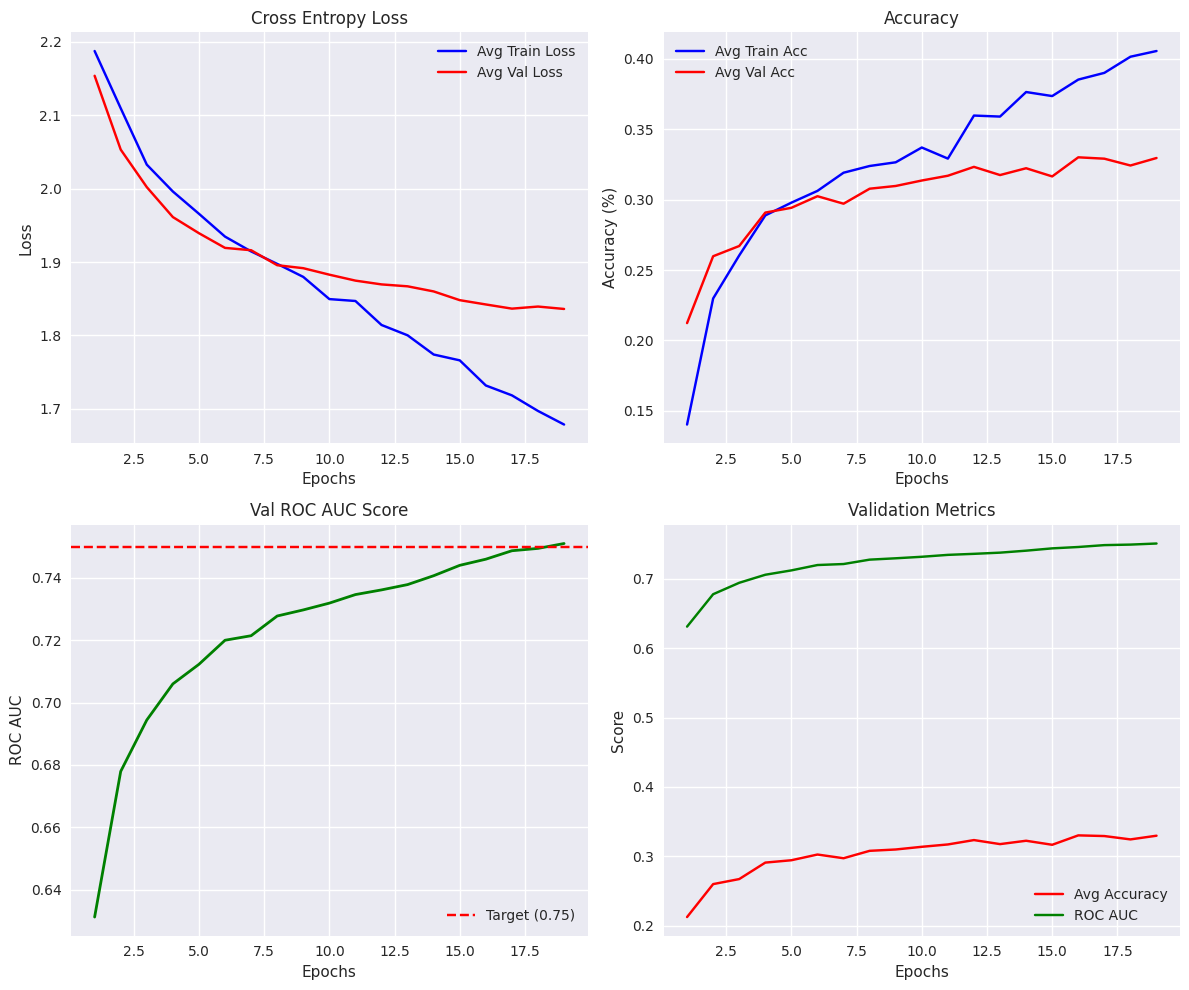

5m 12.9s


In [15]:
start_time = time.time()
model = LeNet5(num_classes=NUM_CLASSES)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_loader, val_loader = get_train_val_loader(
    train_transforms=None, val_transforms=None
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

trained_model, history, best_roc_auc, best_epoch = train_lenet_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_LENET,
    target_roc_auc=TARGET_ROC_AUC,
    lr=LEARNING_RATE,
    device=DEVICE,
)

plot_training_history(history)
# torch.save(model.state_dict(), 'LeNet5_Afric_gest.pt')
total_seconds = time.time() - start_time
print(f"{(total_seconds // 60):.0f}m {(total_seconds % 60):.1f}s")

In [16]:
best_epoch -= 1
cnn_with_aug["model"].append("LeNet5: No augmentation")
cnn_with_aug["params"].append(f"{sum(p.numel() for p in model.parameters()):,}")
cnn_with_aug["time"].append(f"{(total_seconds // 60):.0f}m {(total_seconds % 60):.1f}s")
cnn_with_aug["epoch"].append(best_epoch)
cnn_with_aug["val_roc_auc"].append(history["val_roc_auc"][best_epoch])
cnn_with_aug["avg_val_loss"].append(history["avg_val_loss"][best_epoch])
cnn_with_aug["avg_val_acc"].append(history["avg_val_acc"][best_epoch])
cnn_with_aug["avg_train_loss"].append(history["avg_train_loss"][best_epoch])
cnn_with_aug["avg_train_acc"].append(history["avg_train_acc"][best_epoch])

del model, trained_model
torch.cuda.empty_cache()  # clear GPU cache
collected = gc.collect()  # clear CPU cache

#### 5. Pick any vision model or backbone (resnet18 is recommended as a baseline) from this [library](https://github.com/rwightman/pytorch-image-models). <br>Change the head of your model to a linear layer with one output. Train the model for 2-4 epochs (iterations, traversals over the entire training dataset). <br>You must be able to obtain a ROC AUC greater than 0.9. You are also advised to play with other backbones to get better results.

In [17]:
def create_model(
    model_name: str = "resnet18", num_classes: int = 9, pretrained: bool = True
):

    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=0,  # Remove the default classifier
        in_chans=3,  # Ensure 3 input channels for RGB
    )

    num_features = model.num_features

    head = nn.Linear(num_features, num_classes)

    class WrapperModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            # Extract features from the backbone
            features = self.backbone(x)
            logits = self.head(features)
            return logits

    return WrapperModel(model, head)

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    mixup_cutmix,
    name: str,
    epochs: int = 4,
    lr: float = LEARNING_RATE,
    device: str = "cuda",
    out: dict = cnn_with_aug,
):

    start_time = time.time()

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=1, eta_min=1e-6
    )

    for epoch in range(1, epochs + 1):
        out["model"].append(name)
        out["epoch"].append(epoch)

        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (image, target) in enumerate(train_loader):
            image, target = image.to(device), target.to(device)

            if mixup_cutmix is not None:
                labels_one_hot = F.one_hot(target, num_classes=9).float()
                image, labels_one_hot = mixup_cutmix(image, labels_one_hot)

            optimizer.zero_grad()
            output = model(image)  # Logits, shape (batch_size, 9)

            if mixup_cutmix is not None:
                loss = (
                    (-labels_one_hot * torch.log_softmax(output, dim=1))
                    .sum(dim=1)
                    .mean()
                )
            else:
                loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if mixup_cutmix is not None:
                # For mixed labels, accuracy is approximate
                pred = output.argmax(dim=1)
                # Get original labels from one-hot
                original_labels = labels_one_hot.argmax(dim=1)
                correct += (pred == original_labels).sum().item()
            else:
                pred = output.argmax(dim=1)
                correct += (pred == target).sum().item()

            total += target.size(0)

        out["avg_train_loss"].append(train_loss / len(train_loader))
        out["avg_train_acc"].append(correct / total)

        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for image, target in val_loader:
                image, target = image.to(device), target.to(device)
                output = model(image)

                val_loss += criterion(output, target).item()
                pred = output.argmax(dim=1)
                correct += (pred == target).sum().item()

        out["avg_val_loss"].append(val_loss / len(val_loader))
        out["avg_val_acc"].append(correct / len(val_loader.dataset))
        val_roc_auc = compute_roc_auc(model, val_loader, device)
        out["val_roc_auc"].append(val_roc_auc)

        scheduler.step(val_roc_auc)

    total_seconds = time.time() - start_time
    out["time"].extend(
        [f"{(total_seconds // 60):.0f}m {(total_seconds % 60):.1f}s"] * epochs
    )
    out["params"].extend([f"{sum(p.numel() for p in model.parameters()):,}"] * epochs)

    del optimizer, scheduler

    return model

In [19]:
# use lambda to create one by one model in loop (for conf in models_conf)
models_conf = [
    {
        "name": "efficientnet_b0: No augmentation",
        "model": lambda: create_model(
            model_name="efficientnet_b0", num_classes=9, pretrained=True
        ),
    },
    {
        "name": "densenet121: No augmentation",
        "model": lambda: create_model(
            model_name="densenet121", num_classes=9, pretrained=True
        ),
    },
    {
        "name": "resnet50: No augmentation",
        "model": lambda: create_model(
            model_name="resnet50", num_classes=9, pretrained=True
        ),
    },
    {
        "name": "resnet18: No augmentation",
        "model": lambda: create_model(
            model_name="resnet18", num_classes=9, pretrained=True
        ),
    },
]

for conf in models_conf:
    model = conf["model"]()

    # for more complicated models use BATCH_SIZE // 4 in case of low GPU capabilities
    if conf["name"] != "resnet18: No augmentation":
        train_loader, val_loader = get_train_val_loader(
            train_transforms=None, val_transforms=None, batch_size=BATCH_SIZE // 4
        )
    else:
        train_loader, val_loader = get_train_val_loader(
            train_transforms=None, val_transforms=None, batch_size=BATCH_SIZE
        )

    trained_model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        mixup_cutmix=None,
        name=conf["name"],
        epochs=EPOCHS_RESNET,
        lr=LEARNING_RATE,
        device=DEVICE,
    )

    del model, trained_model
    torch.cuda.empty_cache()  # clear GPU cache
    collected = gc.collect()  # clear CPU cache

out = pd.DataFrame(cnn_with_aug).round(4)
out.loc[out["epoch"] >= 3].reset_index(drop=True)

,model,params,time,epoch,val_roc_auc,avg_val_loss,avg_val_acc,avg_train_loss,avg_train_acc
0,LeNet5: No augmentation,"3,037,313",5m 12.9s,18,0.7510,1.8360,0.3296,1.6785,0.4056
1,efficientnet_b0: No augmentation,"4,019,077",2m 4.8s,3,0.9942,0.2568,0.9229,0.1818,0.9510
2,densenet121: No augmentation,"6,963,081",4m 21.0s,3,0.9930,0.2763,0.9224,0.1604,0.9591
3,resnet50: No augmentation,"23,526,473",4m 27.5s,3,0.9905,0.3515,0.9016,0.4321,0.8739
4,resnet18: No augmentation,"11,181,129",1m 26.9s,3,0.9315,1.3874,0.6563,1.6464,0.6271


#### 6. Apply different augmentations from the [albumentations](https://albumentations.ai/) library and check if they improve the validation score.

| Augmentation | What it does | When you need it |
|--------------|--------------|------------------|
| **RandomRotate90** | Rotates image by 0°, 90°, 180°, or 270° randomly | User's hand may be oriented differently (e.g., phone rotated, different camera angles) |
| **HorizontalFlip** | Mirrors image left-to-right | Gestures are performed with either hand (left/right symmetry) |
| **ShiftScaleRotate** | Translates (shifts), zooms (scales), or rotates image slightly | Hand position varies within frame, camera distance changes, or slight head/body movement |
| **RandomBrightnessContrast** | Randomly changes brightness and contrast levels | Videos recorded under different lighting conditions (indoor/outdoor, day/night, shadows) |
| **HueSaturationValue** | Shifts color hue, saturation, and brightness independently | Different skin tones, colored backgrounds, or varying camera white balance |
| **GaussNoise** | Adds random Gaussian (normal) noise to pixels | Low-quality camera, poor lighting, or compression artifacts in real-world data |
| **Blur** | Smooths image using blur kernel (e.g., Gaussian blur) | Motion blur from fast hand gestures or out-of-focus camera |
| **Resize** | Changes image dimensions to fixed size (e.g., 224×224) | **Always needed** - models require consistent input size |
| **Normalize** | Scales pixel values using mean and std: `(x - mean) / std` | **Always needed for pretrained models** - ensures input matches training distribution of backbone (e.g., ImageNet) |
| **ToTensorV2** | Converts numpy array (H×W×C) to PyTorch tensor (C×H×W) and scales to [0,1] | **Always needed** - PyTorch models expect tensor format |

In [20]:
# same in all models - no transformation
val_transforms = A.Compose(
    [
        A.Resize(*IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

# light augmentation 1-3 transformations
train_transforms = A.Compose(
    [
        A.Resize(*IMG_SIZE),

        # geo
        A.HorizontalFlip(p=0.5),
        # color
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
        
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

train_loader, val_loader = get_train_val_loader(
    train_transforms=train_transforms, val_transforms=val_transforms
)

model = create_model(model_name="resnet18", num_classes=9, pretrained=True)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mixup_cutmix=None,
    name="resnet18: Light augmentation",
    epochs=EPOCHS_RESNET,
    lr=LEARNING_RATE,
    device=DEVICE,
)

del model, trained_model
torch.cuda.empty_cache()  # clear GPU cache
collected = gc.collect()  # clear CPU cache

In [21]:
# Moderate augmentation 4-5 transformations
train_transforms = A.Compose(
    [
        A.Resize(*IMG_SIZE),

        # geo
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        # color
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        # noise
        A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),

        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

train_loader, val_loader = get_train_val_loader(
    train_transforms=train_transforms, val_transforms=val_transforms
)

model = create_model(model_name="resnet18", num_classes=9, pretrained=True)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mixup_cutmix=None,
    name="resnet18: Moderate augmentation",
    epochs=EPOCHS_RESNET,
    lr=LEARNING_RATE,
    device=DEVICE,
)

del model, trained_model
torch.cuda.empty_cache()  # clear GPU cache
collected = gc.collect()  # clear CPU cache

In [22]:
# strong augmentation 6+ transformations
train_transforms = A.Compose(
    [
        A.Resize(*IMG_SIZE),

        # geo
        A.RandomRotate90(p=0.3),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        # color
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
        # histogram
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        # noise
        A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
        # regularization
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, fill_value=0, p=0.3),  

        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
)

train_loader, val_loader = get_train_val_loader(
    train_transforms=train_transforms, val_transforms=val_transforms
)

model = create_model(model_name="resnet18", num_classes=9, pretrained=True)

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    mixup_cutmix=None,
    name="resnet18: Strong augmentation",
    epochs=EPOCHS_RESNET,
    lr=LEARNING_RATE,
    device=DEVICE,
)

del model, trained_model
torch.cuda.empty_cache()  # clear GPU cache
collected = gc.collect()  # clear CPU cache

out = pd.DataFrame(cnn_with_aug).round(4)
out.loc[out["epoch"] >= 3].reset_index(drop=True)

,model,params,time,epoch,val_roc_auc,avg_val_loss,avg_val_acc,avg_train_loss,avg_train_acc
0,LeNet5: No augmentation,"3,037,313",5m 12.9s,18,0.7510,1.8360,0.3296,1.6785,0.4056
1,efficientnet_b0: No augmentation,"4,019,077",2m 4.8s,3,0.9942,0.2568,0.9229,0.1818,0.9510
2,densenet121: No augmentation,"6,963,081",4m 21.0s,3,0.9930,0.2763,0.9224,0.1604,0.9591
3,resnet50: No augmentation,"23,526,473",4m 27.5s,3,0.9905,0.3515,0.9016,0.4321,0.8739
4,resnet18: No augmentation,"11,181,129",1m 26.9s,3,0.9315,1.3874,0.6563,1.6464,0.6271
5,resnet18: Light augmentation,"11,181,129",1m 27.7s,3,0.9293,1.3884,0.6481,1.6573,0.5977
6,resnet18: Moderate augmentation,"11,181,129",1m 29.6s,3,0.8893,1.6762,0.5507,1.9670,0.3813
7,resnet18: Strong augmentation,"11,181,129",1m 29.8s,3,0.8638,1.8432,0.5356,2.0524,0.3485


#### 7. Implement MixUp and CutMix augmentations and test them in your pipeline; check if they improve the validation score.

<img src="data/cut_mix2.png" alt="cut_mix" style="width: 30%; height: auto;">

In [23]:
@dataclass
class MixUp:
    """
    MixUp augmentation: blends two images and their labels
    Paper: https://arxiv.org/abs/1710.09412
    """

    alpha: float = 0.2

    def __call__(
        self, images: torch.Tensor, labels: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:

        if self.alpha > 0:
            lambda_ = np.random.beta(self.alpha, self.alpha)
        else:
            lambda_ = 1.0

        batch_size = images.size(0)
        index = torch.randperm(batch_size).to(images.device)

        mixed_images = lambda_ * images + (1 - lambda_) * images[index]

        # Labels are one-hot encoded
        mixed_labels = lambda_ * labels + (1 - lambda_) * labels[index]

        return mixed_images, mixed_labels

In [24]:
@dataclass
class CutMix:
    """
    CutMix augmentation: cuts and pastes patches between images
    Paper: https://arxiv.org/abs/1905.04899
    """

    alpha: float = 1.0

    def rand_bbox(
        self, size: Tuple[int, ...], lambda_: float
    ) -> Tuple[int, int, int, int]:
        W = size[2]
        H = size[3]

        # Calculate cut ratio
        cut_ratio = np.sqrt(1.0 - lambda_)
        cut_w = int(W * cut_ratio)
        cut_h = int(H * cut_ratio)

        # Uniformly choose center
        cx = np.random.randint(W)
        cy = np.random.randint(H)

        # Calculate bounding box boundaries
        x1 = np.clip(cx - cut_w // 2, 0, W)
        x2 = np.clip(cx + cut_w // 2, 0, W)
        y1 = np.clip(cy - cut_h // 2, 0, H)
        y2 = np.clip(cy + cut_h // 2, 0, H)

        return x1, y1, x2, y2

    def __call__(
        self, images: torch.Tensor, labels: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size = images.size(0)
        index = torch.randperm(batch_size).to(images.device)

        if self.alpha > 0:
            lambda_ = np.random.beta(self.alpha, self.alpha)
        else:
            lambda_ = 1.0

        # Generate bounding box
        x1, y1, x2, y2 = self.rand_bbox(images.shape, lambda_)

        # Apply cutmix
        mixed_images = images.clone()
        mixed_images[:, :, y1:y2, x1:x2] = images[index, :, y1:y2, x1:x2]

        # Adjust lambda based on actual cut area
        lambda_ = 1 - ((x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2)))

        # Mix labels
        mixed_labels = lambda_ * labels + (1 - lambda_) * labels[index]

        return mixed_images, mixed_labels

In [25]:
for name, mixup_cutmix in (
    ("resnet18: MixUp augmentation", MixUp()),
    ("resnet18: CutMix augmentation", CutMix()),
):

    train_loader, val_loader = get_train_val_loader(
        train_transforms=None, val_transforms=None
    )

    model = create_model(model_name="resnet18", num_classes=9, pretrained=True)

    trained_model = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        mixup_cutmix=mixup_cutmix,
        name=name,
        epochs=EPOCHS_RESNET,
        lr=LEARNING_RATE,
        device=DEVICE,
    )

    del model, trained_model
    torch.cuda.empty_cache()  # clear GPU cache
    collected = gc.collect()  # clear CPU cache

out = pd.DataFrame(cnn_with_aug).round(4)
out.loc[out["epoch"] >= 3].reset_index(drop=True)

,model,params,time,epoch,val_roc_auc,avg_val_loss,avg_val_acc,avg_train_loss,avg_train_acc
0,LeNet5: No augmentation,"3,037,313",5m 12.9s,18,0.7510,1.8360,0.3296,1.6785,0.4056
1,efficientnet_b0: No augmentation,"4,019,077",2m 4.8s,3,0.9942,0.2568,0.9229,0.1818,0.9510
2,densenet121: No augmentation,"6,963,081",4m 21.0s,3,0.9930,0.2763,0.9224,0.1604,0.9591
3,resnet50: No augmentation,"23,526,473",4m 27.5s,3,0.9905,0.3515,0.9016,0.4321,0.8739
4,resnet18: No augmentation,"11,181,129",1m 26.9s,3,0.9315,1.3874,0.6563,1.6464,0.6271
5,resnet18: Light augmentation,"11,181,129",1m 27.7s,3,0.9293,1.3884,0.6481,1.6573,0.5977
6,resnet18: Moderate augmentation,"11,181,129",1m 29.6s,3,0.8893,1.6762,0.5507,1.9670,0.3813
7,resnet18: Strong augmentation,"11,181,129",1m 29.8s,3,0.8638,1.8432,0.5356,2.0524,0.3485
8,resnet18: MixUp augmentation,"11,181,129",1m 28.0s,3,0.9289,1.4466,0.6743,1.7342,0.6194
9,resnet18: CutMix augmentation,"11,181,129",1m 28.1s,3,0.9034,1.8190,0.6083,2.0135,0.4021


#### Bonus part.
#### B1. Add Test-Time-Augmentation (TTA) option to your code. <br>For example, try averaging the predictions of horizontally flipped and original images. What is your gain in terms of ROC AUC score?


In [26]:
model = LeNet5(num_classes=NUM_CLASSES)

train_loader, val_loader = get_train_val_loader(
    train_transforms=None, val_transforms=None
)

trained_model, history, best_roc_auc, best_epoch = train_lenet_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_RESNET,
    target_roc_auc=TARGET_ROC_AUC,
    lr=LEARNING_RATE,
    device=DEVICE,
    # use kwarg tta
    use_tta=True,
)

del model, trained_model
torch.cuda.empty_cache()  # clear GPU cache
collected = gc.collect()  # clear CPU cache

Improvement: - 0.0047
New best model! Epoch: 1, ROC AUC: 0.5939
Improvement: - 0.0070
New best model! Epoch: 2, ROC AUC: 0.6202
Improvement: - 0.0078
New best model! Epoch: 3, ROC AUC: 0.6567
Training completed!
Best ROC AUC: 0.6567
Best Avg Validation Accuracy: 0.24%


#### * Sources
- adam https://arxiv.org/pdf/1412.6980
- mixup https://arxiv.org/abs/1710.09412
- cutmix https://arxiv.org/abs/1905.04899

In [27]:
total_seconds = time.time() - notebook_time
print(f"{(total_seconds // 60):.0f}m {(total_seconds % 60):.1f}s")

26m 7.6s
